In [1]:
from strategies import *
from scipy.signal import savgol_filter
import pandas as pd

if __name__ == '__main__':
    
    df = pd.read_csv("../../backtesting/data/GOOGL/GOOGL.USUSD_Candlestick_5_M_ASK_05.10.2022-05.10.2024.csv")

    df['Gmt time']=df["Gmt time"].str.replace(".000","")
    df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
    datetime_est=pd.to_datetime(df["Gmt time"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
    
    fromTodayStart = '2022-10-05 09:30:00'
    toNow   = '2022-11-05 16:00:00'
    df = df[datetime_est.between(fromTodayStart, toNow)].copy()

    df.rename(columns={"Open": "open"}, inplace=True)
    df.rename(columns={"High": "high"}, inplace=True)
    df.rename(columns={"Low": "low"}, inplace=True)
    df.rename(columns={"Volume": "volume"}, inplace=True)
    df.rename(columns={"Close": "close"}, inplace=True)
    df.rename(columns={"Gmt time": "time"}, inplace=True)

    df=df[df.notnull().all(axis=1)]
    df=df[(df.volume != 0)]
    df=df[df.high!=df.low]
    
    df.reset_index(drop=True, inplace=True)
    df['index']=df.index
    
    df.set_index("time", inplace=True, drop=True)
    
    df = df[['index','high','low','close','volume','open']] 

    result = squeez(df)

    #result = result[result["position"]==1]

    result['side'] = np.where(result.position==1,'B',
                              np.where(result.position==-1,'S', 'N'))

    result_df = result[['date_est','time_est','index','symbol','qty','price','side']]
    
    df_log_sequence = pd.DataFrame(result_df, columns=['Date','Time','Candle','Symbol','Quantity','Price','Side'])

    print(result_df)

    
    '''
    for candle in range(0, len(result)):
        
        position = (result.iloc[candle]).position
        date = (result.iloc[candle]).date_est
        time = (result.iloc[candle]).time_est
        buying_price = (result.iloc[candle]).buyingPrice
        selling_price = (result.iloc[candle]).sellingPrice
        close_smooth = (result.iloc[candle]).close_smooth
        close = (result.iloc[candle]).close
        squeezeCloseToEma = (result.iloc[candle]).squeezeCloseToEma
        squeezedArea = (result.iloc[candle]).squeezedArea
        ema25 = (result.iloc[candle]).ema25
        
        if (position==1):
            trans = [date, time, candle, 'GOOGLE', 10, round(buying_price, 2), close, close_smooth, squeezedArea, squeezeCloseToEma, 'B']
        elif (position==-1):  
            trans = [date, time, candle, 'GOOGLE', 10, round(selling_price, 2), close, close_smooth, squeezedArea, squeezeCloseToEma,'S']
        else:
            trans = [date, time, candle, 'GOOGLE', 10, 0, close, close_smooth, squeezedArea, squeezeCloseToEma,'N']
            
        log_sequence.append(trans)
    '''
        
    #result.to_csv('live_test_script.csv', index=False)

                       date_est  time_est  index  symbol  qty    close side
time                                                                       
2022-10-05 13:30:00  2022-10-05  09:30:00      0  GOOGLE   10  100.364    N
2022-10-05 13:35:00  2022-10-05  09:35:00      1  GOOGLE   10  100.014    N
2022-10-05 13:40:00  2022-10-05  09:40:00      2  GOOGLE   10   99.584    N
2022-10-05 13:45:00  2022-10-05  09:45:00      3  GOOGLE   10   99.873    N
2022-10-05 13:50:00  2022-10-05  09:50:00      4  GOOGLE   10   99.533    N
...                         ...       ...    ...     ...  ...      ...  ...
2022-11-04 19:35:00  2022-11-04  15:35:00   1765  GOOGLE   10   86.163    B
2022-11-04 19:40:00  2022-11-04  15:40:00   1766  GOOGLE   10   86.484    B
2022-11-04 19:45:00  2022-11-04  15:45:00   1767  GOOGLE   10   86.374    B
2022-11-04 19:50:00  2022-11-04  15:50:00   1768  GOOGLE   10   86.434    B
2022-11-04 19:55:00  2022-11-04  15:55:00   1769  GOOGLE   10   86.653    B

[1770 rows 

/tmp/ipykernel_14252/2698590959.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['side'] = np.where(result.position==1,'B',


In [2]:
def positionArea(x):
    extraSpace = .80
    if (x['position']==POSITION['LONG'].value):
        return x['low']-extraSpace
    elif (x['position']==POSITION['SHORT'].value):
        return x['high']+extraSpace    
    else:
        return np.nan
        
def posibleEntryArea(x):
    extraSpace = .50
    if (x['posible_entry']==POSITION['LONG'].value):
        return x['low']-extraSpace
    elif (x['posible_entry']==POSITION['SHORT'].value):
        return x['high']+extraSpace    
    else:
        return np.nan
                
def squeezeCloseToEmaArea(x):
    extraSpace = .80
    if (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low']-extraSpace
    elif (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high']+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .50
    if (x['squeezedArea']==EMA25['PRICE_ACCION_OVER_EMA'].value):
        return x['low']-extraSpace
    elif (x['squeezedArea']==EMA25['PRICE_ACCION_UNDER_EMA'].value):
        return x['high']+extraSpace
    else:
        return np.nan
        
with pd.option_context("mode.copy_on_write", True): 
    #result['squezzeArea'] = result.apply(lambda row: squezzeArea(row), axis=1)
    #result['squeezeCloseToEmaArea'] = result.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
    result['posibleEntry'] = result.apply(lambda row: posibleEntryArea(row), axis=1)
    result['positionArea'] = result.apply(lambda row: positionArea(row), axis=1)

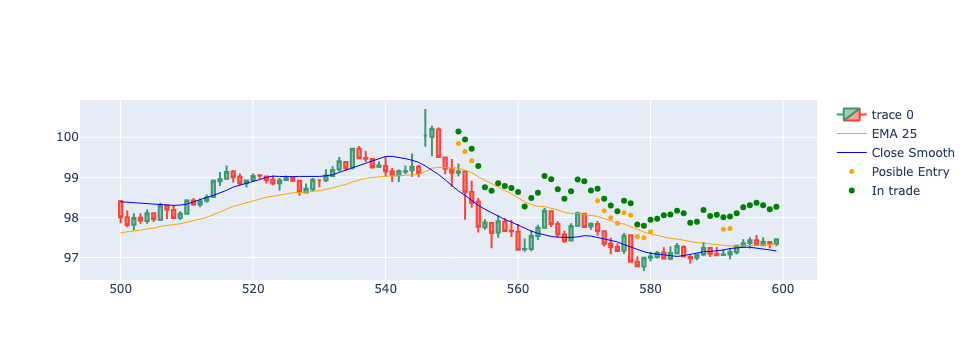

In [6]:
import plotly.io as pio
import plotly.graph_objects as go  

dfpl = result[500:600]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl['index'], 
            open=dfpl['open'],
            high=dfpl['high'],
            low=dfpl['low'],
            close=dfpl['close']),
        go.Scatter(
            x=dfpl['index'], 
            y=dfpl['ema25'],
            line=dict(color='orange', width=1), 
            name="EMA 25"),
        go.Scatter(
            x=dfpl['index'], 
            y=dfpl['close_smooth'],
            line=dict(color='blue', width=1), 
            name="Close Smooth")
    ]
)

#fig.add_scatter(x=dfpl['index'], y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
#fig.add_scatter(x=dfpl['index'], y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl['index'], y=dfpl['posibleEntry'], mode="markers", marker=dict(size=5, color="orange"), name="Posible Entry")
fig.add_scatter(x=dfpl['index'], y=dfpl['positionArea'], mode="markers", marker=dict(size=6, color="green"), name="In trade")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()